<h1 style="text-align:center; color:#2E86C1;"><b>Clothing Type Prediction via Computer Vision and Image Processing</b></h1>

In this project, a deep learning model is developed to classify clothing items into various categories. **Computer Vision** methods are utilized for feature extraction, and **Image Processing** techniques are applied for data preparation and augmentation.

<h2 style="color:#117A65;">1. Necessary Libraries and Tools are Imported</h2>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


<h2 style="color:#117A65;">1.5 Automatic Dataset Download</h2>

This cell ensures that the training dataset is downloaded locally via the Kaggle API. It safely bypasses corrupted zip files by downloading a functional subset of images individually.

In [2]:
import os
import pandas as pd
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor

# Configuration
DATASET_NAME = "agrigorev/clothing-dataset-full"
SUBSET_SIZE = 500
PROCESSED_FOLDER = "images_subset"
CSV_FILE = "images.csv"

def setup_dataset():
    if not os.path.exists(PROCESSED_FOLDER):
        os.makedirs(PROCESSED_FOLDER)

    print(f"Loading {CSV_FILE}...")
    if not os.path.exists(CSV_FILE):
        print(f"Error: {CSV_FILE} not found. Please ensure it is in the same directory.")
        return

    df = pd.read_csv(CSV_FILE)
    df = df[~df['label'].isin(['Not sure', 'Skip', 'Other'])]
    
    subset_df = df.head(SUBSET_SIZE)
    image_ids = subset_df['image'].tolist()

    # Check if images are already downloaded
    existing_images = [f for f in os.listdir(PROCESSED_FOLDER) if f.endswith('.jpg')]
    if len(existing_images) >= SUBSET_SIZE:
        print(f"Dataset already downloaded! Found {len(existing_images)} images in '{PROCESSED_FOLDER}'.")
        return

    print(f"Downloading {len(image_ids)} images individually to bypass huge zip files...")
    
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
    except Exception as e:
        print(f"Kaggle API setup failed: {e}")
        print("Please ensure your kaggle.json is configured correctly.")
        return

    def download_img(img_id):
        target_file = os.path.join(PROCESSED_FOLDER, f"{img_id}.jpg")
        if os.path.exists(target_file):
            return True
        try:
            api.dataset_download_file(DATASET_NAME, f"images_compressed/{img_id}.jpg", path=PROCESSED_FOLDER)
            return True
        except Exception:
            try:
                api.dataset_download_file(DATASET_NAME, f"images_original/{img_id}.jpg", path=PROCESSED_FOLDER)
                return True
            except:
                return False

    with ThreadPoolExecutor(max_workers=10) as executor:
        results = list(tqdm(executor.map(download_img, image_ids), total=len(image_ids)))

    success_count = sum(1 for r in results if r)
    print(f"\nSuccess! {success_count} images downloaded to '{PROCESSED_FOLDER}'.")

# Run the setup
setup_dataset()


Loading images.csv...
Dataset already downloaded! Found 500 images in 'images_subset'.


<h2 style="color:#117A65;">2. Dataset is Loaded and Explored</h2>

The `images.csv` file is read to link image IDs with their corresponding labels. The processed subset created by the setup script is utilized here.

In [3]:
DATA_DIR = 'images_subset'
df = pd.read_csv('images.csv')

# Preprocess filenames to match the local path
df['filename'] = df['image'] + '.jpg'

# Check which images actually exist in our subset folder
existing_images = os.listdir(DATA_DIR)
df = df[df['filename'].isin(existing_images)].reset_index(drop=True)

print(f"Total images in subset: {len(df)}")
df.head()

Total images in subset: 500


,image,sender_id,label,kids,filename
0,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False,ea7b6656-3f84-4eb3-9099-23e623fc1018.jpg
1,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa.jpg
2,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False,3b86d877-2b9e-4c8b-a6a2-1d87513309d0.jpg
3,5d3a1404-697f-479f-9090-c1ecd0413d27,138,Shorts,False,5d3a1404-697f-479f-9090-c1ecd0413d27.jpg
4,b0c03127-9dfb-4573-8934-1958396937bf,138,Shirt,False,b0c03127-9dfb-4573-8934-1958396937bf.jpg


<h3 style="color:#A04000;">Ambiguous Labels are Filtered</h3>
Classes that are determined to be ambiguous or irrelevant are removed from the dataset.

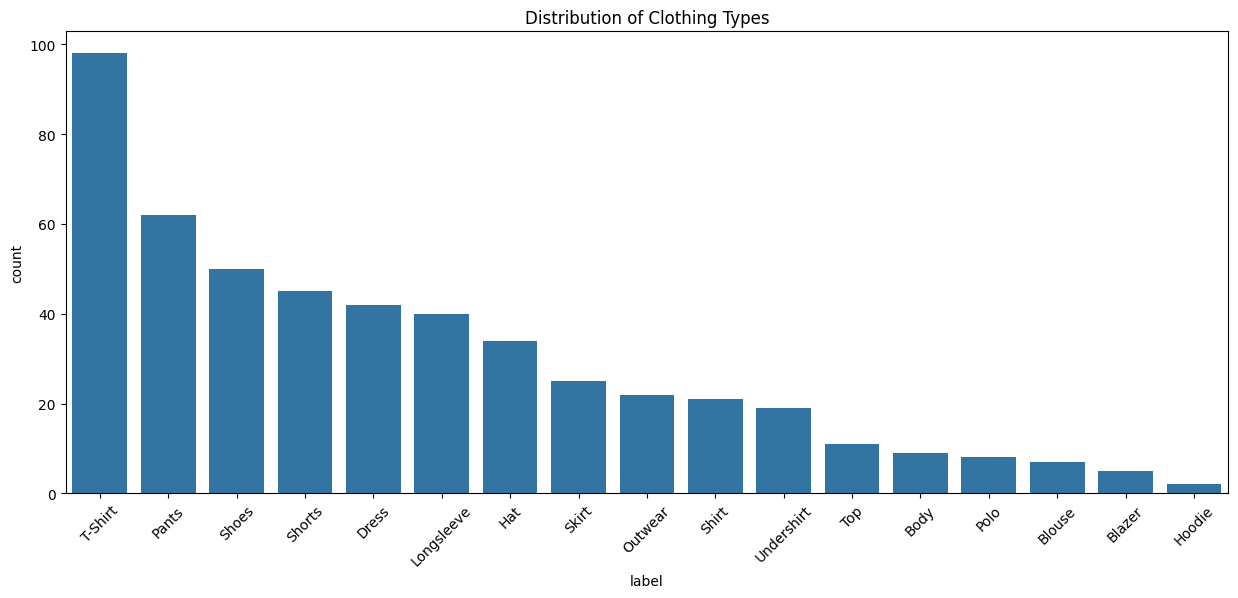

In [4]:
exclude_labels = ['Not sure', 'Skip', 'Other']
df = df[~df['label'].isin(exclude_labels)]

plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Clothing Types')
plt.show()

<h2 style="color:#117A65;">3. Image Data is Augmented and Generated</h2>

The data is split into training and testing sets. **Image Processing** via `ImageDataGenerator` is employed for real-time augmentation (rotation, zoom, flips).

In [5]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, 
    directory=DATA_DIR,
    x_col='filename', 
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_dataframe(
    train_df, 
    directory=DATA_DIR,
    x_col='filename', 
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df, 
    directory=DATA_DIR,
    x_col='filename', 
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 320 validated image filenames belonging to 17 classes.
Found 80 validated image filenames belonging to 17 classes.
Found 100 validated image filenames belonging to 16 classes.


<h2 style="color:#117A65;">4. Transfer Learning Model is Constructed</h2>

**MobileNetV2** is implemented as the base model for efficient feature extraction. Custom layers are appended for the specific classification task.

In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,922,577 (11.15 MB)

 Trainable params: 664,593 (2.54 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

<h2 style="color:#117A65;">5. Model is Trained and Optimized</h2>

Training is executed with callbacks for Early Stopping and Learning Rate reduction to ensure optimal convergence.

In [7]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, verbose=1)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.2812 - loss: 2.6634 - val_accuracy: 0.5375 - val_loss: 1.6727 - learning_rate: 0.0010
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5312 - loss: 1.6990 - val_accuracy: 0.5875 - val_loss: 1.3981 - learning_rate: 0.0010
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6438 - loss: 1.2567 - val_accuracy: 0.5750 - val_loss: 1.2814 - learning_rate: 0.0010
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6406 - loss: 1.1759 - val_accuracy: 0.6125 - val_loss: 1.1720 - learning_rate: 0.0010
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7469 - loss: 0.9136 - val_accuracy: 0.6500 - val_loss: 1.1915 - learning_rate: 0.0010
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7469 - loss: 0.7303 - val_accuracy: 0.6375 - val_loss: 1.2023 - learning_rate: 0.0010
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7692 - loss: 0.6344
Epoch 7: ReduceLR

In [8]:
import json
# Save the model (HDF5 format is lightweight, typically < 15MB for MobileNetV2)
model.save('clothing_model.h5')
# Save the class labels
with open('classes.json', 'w', encoding='utf-8') as f:
    json.dump(train_generator.class_indices, f)
print('Model and classes saved successfully!')

Model and classes saved successfully!


<h2 style="color:#117A65;">6. Performance Results are Visualized</h2>

Accuracy and Loss curves are plotted to analyze the training progress. A confusion matrix is generated to evaluate class-wise performance.

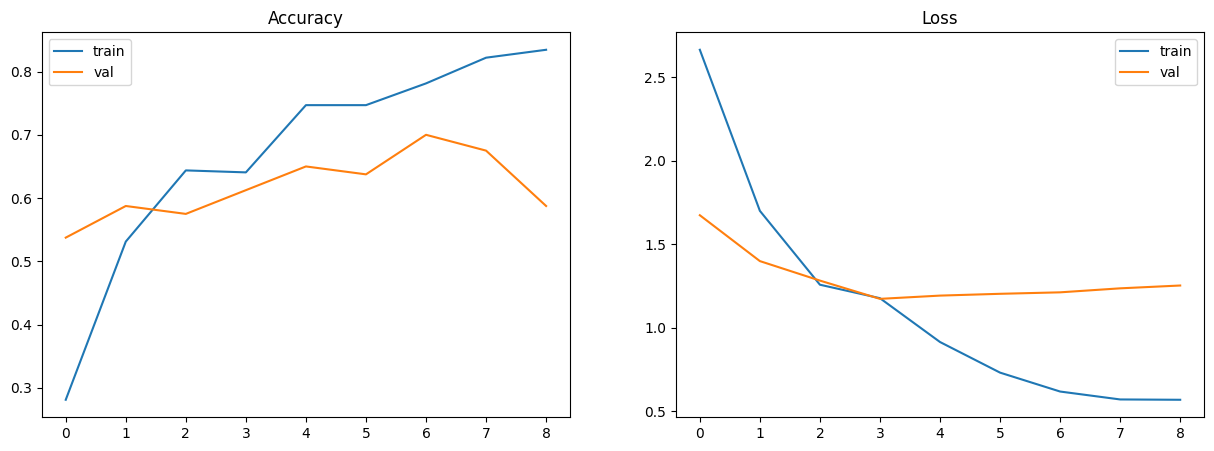

In [9]:
# Plot Accuracy & Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.legend()

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step  


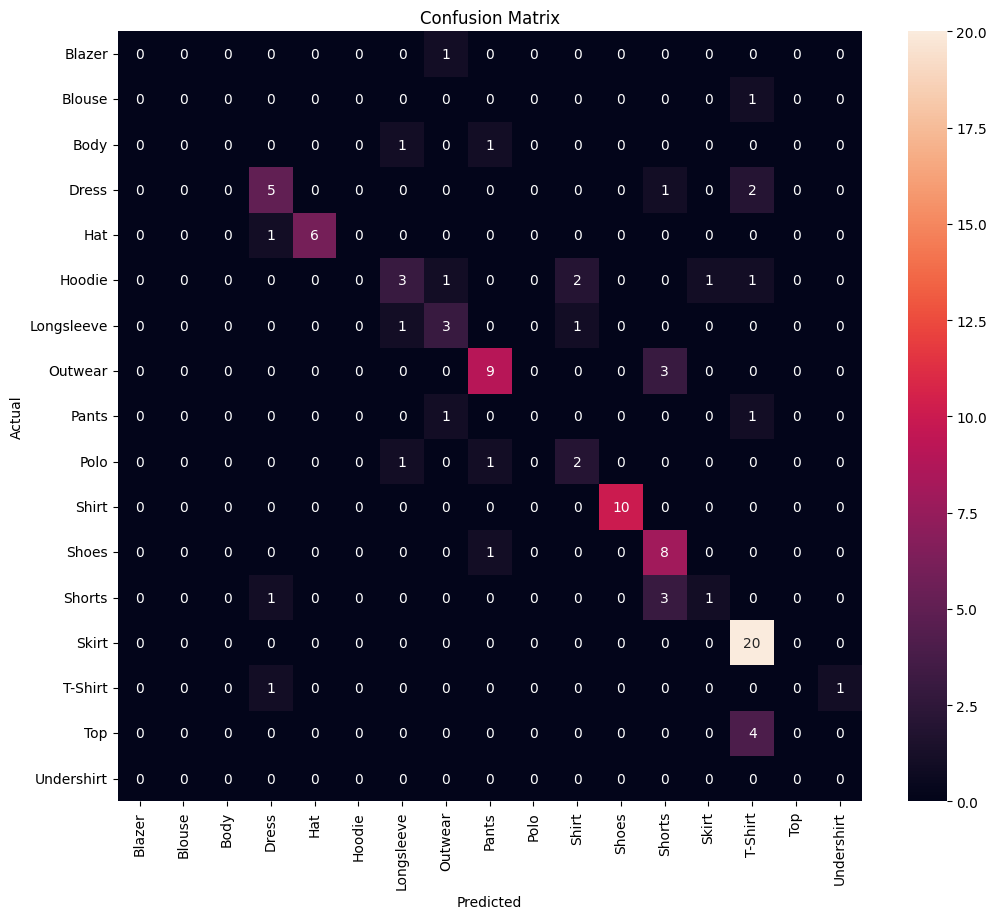

In [10]:
# Predict on test data
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<h2 style="color:#117A65;">7. Predictions are Performed on New Data</h2>

A custom function is defined to predict the clothing type from a provided image file path using the trained model.

In [11]:
def predict_clothing(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    class_labels = list(train_generator.class_indices.keys())
    
    return class_labels[class_idx], prediction[0][class_idx]

# Example Usage:
print(predict_clothing('images_subset/19b8f13e-9f17-4fcc-a4cd-7496672b1675.jpg'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
('Hat', np.float32(0.37673172))
